# Week 10 – Colab 2: Feature Extractor vs Fine-Tuning

In this notebook you will:

1. Train **Experiment A** – ResNet18 as a frozen feature extractor  
2. Train **Experiment B** – ResNet18 with last block + classifier fine-tuned  
3. Compare training and test performance  
4. Reflect on which strategy might be better for a **robotic system**


In [ ]:
#@title Setup: Imports, Device and CIFAR-10 Data

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True,
                                             download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False,
                                            download=True, transform=transform)

# ==== STUDENT: YOU CAN ADJUST BATCH SIZE AND EPOCHS BELOW ====
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

num_classes = 10  # CIFAR-10


Using device: cuda


In [ ]:
#@title Helper Function: Build ResNet18 Model

def build_resnet18_model(feature_extractor=True):
    """
    Builds a ResNet18 model for CIFAR-10.
    If feature_extractor=True, freezes all layers except final fc.
    If feature_extractor=False, we will later unfreeze some layers manually.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Freeze all layers initially
    for param in model.parameters():
        param.requires_grad = False

    # Replace final layer with new classifier for CIFAR-10
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    # If feature_extractor is True, only fc is trainable (already set)
    # If False, we'll unfreeze some layers in a later cell
    model = model.to(device)
    return model


In [ ]:
#@title Helper Functions: Train + Validate + Evaluate

def train_and_validate(model, train_loader, test_loader, criterion, optimizer, num_epochs=1):
    """
    Trains the model and records:
    - train_loss
    - train_acc
    - val_acc (on the test_loader, used here as validation)

    Returns a history dict with lists for each metric.
    """
    history = {"train_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        # ---- Training ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = correct / total

        # ---- "Validation" on test set ----
        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total_val += labels.size(0)
                correct_val += predicted.eq(labels).sum().item()
        val_acc = correct_val / total_val

        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {epoch_loss:.4f} - "
              f"Train Acc: {epoch_acc:.4f} - "
              f"Val Acc: {val_acc:.4f}")

    return history


def evaluate_model(model, test_loader):
    """
    Final evaluation on the test set after training.
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_acc = correct / total
    print(f"Final Test Accuracy: {test_acc:.4f}")
    return test_acc


In [ ]:
#@title Experiment A: Feature Extractor (All Layers Frozen Except FC)

criterion = nn.CrossEntropyLoss()

# ==== STUDENT: TRY CHANGING THE NUMBER OF EPOCHS ====
num_epochs_A = 3  # use >=3 so you can see a proper curve

model_A = build_resnet18_model(feature_extractor=True)

optimizer_A = optim.Adam(
    filter(lambda p: p.requires_grad, model_A.parameters()),
    lr=1e-3  # ==== STUDENT: YOU CAN TRY 5e-4 OR 2e-3 ====
)

print("Experiment A: training feature extractor model...")
history_A = train_and_validate(model_A, train_loader, test_loader,
                               criterion, optimizer_A, num_epochs=num_epochs_A)

print("Experiment A: evaluating on test set...")
test_acc_A = evaluate_model(model_A, test_loader)


Experiment A: training feature extractor model...
Epoch [1/3] - Train Loss: 0.8267 - Train Acc: 0.7324 - Val Acc: 0.7916
Epoch [2/3] - Train Loss: 0.6167 - Train Acc: 0.7881 - Val Acc: 0.7962
Epoch [3/3] - Train Loss: 0.5902 - Train Acc: 0.7961 - Val Acc: 0.8004
Experiment A: evaluating on test set...
Final Test Accuracy: 0.8004


In [ ]:
#@title Experiment B: Fine-Tuning Last Block (layer4 + fc)

criterion = nn.CrossEntropyLoss()

# ==== STUDENT: TRY CHANGING THE NUMBER OF EPOCHS ====
num_epochs_B = 3  # same as A so comparison is fair

model_B = build_resnet18_model(feature_extractor=False)

# Unfreeze last block (layer4) + final layer (fc)
for name, param in model_B.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

# Smaller LR for fine-tuning
optimizer_B = optim.Adam(
    filter(lambda p: p.requires_grad, model_B.parameters()),
    lr=1e-4  # ==== STUDENT: YOU CAN TRY 5e-5 OR 5e-4 ====
)

print("Trainable parameters in Experiment B:",
      sum(p.numel() for p in model_B.parameters() if p.requires_grad))

print("Experiment B: training fine-tuned model...")
history_B = train_and_validate(model_B, train_loader, test_loader,
                               criterion, optimizer_B, num_epochs=num_epochs_B)

print("Experiment B: evaluating on test set...")
test_acc_B = evaluate_model(model_B, test_loader)


Trainable parameters in Experiment B: 8398858
Experiment B: training fine-tuned model...
Epoch [1/3] - Train Loss: 0.4296 - Train Acc: 0.8575 - Val Acc: 0.8979
Epoch [2/3] - Train Loss: 0.1414 - Train Acc: 0.9551 - Val Acc: 0.9061
Epoch [3/3] - Train Loss: 0.0462 - Train Acc: 0.9880 - Val Acc: 0.9013
Experiment B: evaluating on test set...
Final Test Accuracy: 0.9013


Experiment A (Feature Extractor) - Final Test Acc: 0.8004
Experiment B (Fine-Tuning)      - Final Test Acc: 0.9013


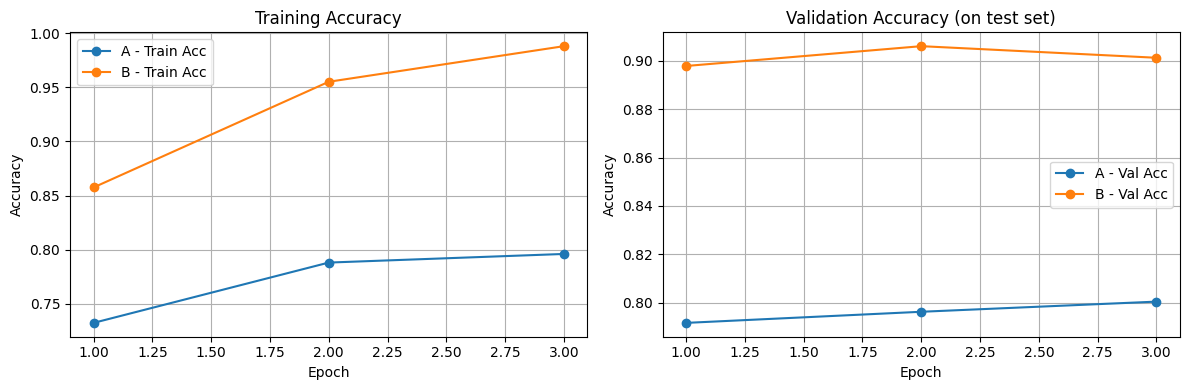

In [ ]:
#@title Compare Experiment A vs B (Training + Validation Curves)

import matplotlib.pyplot as plt

print(f"Experiment A (Feature Extractor) - Final Test Acc: {test_acc_A:.4f}")
print(f"Experiment B (Fine-Tuning)      - Final Test Acc: {test_acc_B:.4f}")

epochs_A = range(1, len(history_A["train_acc"]) + 1)
epochs_B = range(1, len(history_B["train_acc"]) + 1)

plt.figure(figsize=(12,4))

# ---- Plot training accuracy ----
plt.subplot(1, 2, 1)
plt.plot(epochs_A, history_A["train_acc"], marker="o", label="A - Train Acc")
plt.plot(epochs_B, history_B["train_acc"], marker="o", label="B - Train Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()
plt.grid(True)

# ---- Plot validation accuracy ----
plt.subplot(1, 2, 2)
plt.plot(epochs_A, history_A["val_acc"], marker="o", label="A - Val Acc")
plt.plot(epochs_B, history_B["val_acc"], marker="o", label="B - Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy (on test set)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## ✏️ Reflection: Which Strategy for a Robot?

1. Which experiment performed better on the **test set**? Why do you think that is?
2. If you only had **very few images** from your robot's environment,
   which strategy would you choose first? Why?
3. If your robot was **battery-powered with limited compute**, would you:
   - keep the model mostly frozen, or  
   - fine-tune many layers?  
   Explain your reasoning.
